# Model 2: Price Elasticity

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = Path.cwd() / "nyc_taxi_ml_dataset_2024_2025.parquet"

df = pd.read_parquet(DATA_PATH)
print(df.shape)
df.head()

(38202226, 26)


,pickup_datetime,provider,dropoff_datetime,PULocationID,DOLocationID,trip_distance,trip_time,fare_amount,tax,tolls_amount,...,cost_per_mile,temperature,precipitation,weathercode,windspeed,weather_clear,weather_cloudy,weather_rain,weather_snow,dataset_split
0,2024-01-23 00:50:15,1,2024-01-23 01:21:53,132,33,26.62,1898,96.8,0.5,0.0,...,4.542074,30.2,0.0,3.0,11.6,0,1,0,0.0,train
1,2024-01-14 20:21:20,1,2024-01-14 20:26:25,236,43,0.76,305,7.2,0.5,0.0,...,18.026316,27.6,0.0,1.0,12.1,0,1,0,0.0,train
2,2024-01-23 00:23:16,1,2024-01-23 00:25:55,246,50,0.70,159,5.8,0.5,0.0,...,20.057143,30.2,0.0,3.0,11.6,0,1,0,0.0,train
3,2024-01-13 20:31:32,1,2024-01-13 20:40:59,113,90,1.00,567,10.0,0.5,0.0,...,17.250000,39.5,0.0,1.0,16.7,0,1,0,0.0,train
4,2024-01-10 09:23:39,1,2024-01-10 09:29:49,170,234,0.70,370,7.2,0.5,0.0,...,19.142857,47.5,0.0,3.0,16.7,0,1,0,0.0,train


In [3]:
df.dtypes

pickup_datetime         datetime64[us]
provider                         int64
dropoff_datetime        datetime64[us]
PULocationID                     int32
DOLocationID                     int32
trip_distance                  float64
trip_time                        int64
fare_amount                    float64
tax                            float64
tolls_amount                   float64
total_amount                   float64
congestion_surcharge           float64
airport_fee                    float64
cbd_congestion_fee             float64
speed_mph                      float64
in_cbd_zone                      int64
cost_per_mile                  float64
temperature                    float64
precipitation                  float64
weathercode                    float64
windspeed                      float64
weather_clear                     int8
weather_cloudy                    int8
weather_rain                      int8
weather_snow                   float64
dataset_split            

### Step 1A - Create Time Columns

In [4]:
# Extract time components
df["pickup_date"] = df["pickup_datetime"].dt.date
df["pickup_hour"] = df["pickup_datetime"].dt.hour
df["dow"] = df["pickup_datetime"].dt.dayofweek  # 0=Mon
df["year"] = df["pickup_datetime"].dt.year

### Step 1B - Count Distinct (zone, date, hour)

In [5]:
distinct_bins = (
    df[["PULocationID", "pickup_date", "pickup_hour"]]
    .drop_duplicates()
)

print("Number of distinct (zone, date, hour) bins:", len(distinct_bins))

Number of distinct (zone, date, hour) bins: 3558513


In [6]:
unique_zones = df["PULocationID"].nunique()
unique_dates = df["pickup_date"].nunique()

print("Zones:", unique_zones)
print("Dates:", unique_dates)
print("Max possible bins:", unique_zones * unique_dates * 24)

Zones: 261
Dates: 674
Max possible bins: 4221936


Observed bins: 3,558,513
Max possible bins: 4,221,936
Missing bins: ~663,423
That means about 16% of zone-hour combinations had zero trips.

### Step 1C - Build the Aggregated Demand Panel

In [7]:
df["is_airport"] = (df["airport_fee"] > 0).astype(int)

panel = (
    df
    .groupby(
        ["PULocationID", "pickup_date", "pickup_hour", "dow"],
        as_index=False
    )
    .agg(
        Q=("total_amount", "size"),  # trip count (demand)
        avg_total_amount=("total_amount", "mean"),
        avg_fare_amount=("fare_amount", "mean"),
        avg_cost_per_mile=("cost_per_mile", "mean"),
        avg_trip_distance=("trip_distance", "mean"),
        avg_trip_time=("trip_time", "mean"),
        avg_speed=("speed_mph", "mean"),
        share_cbd=("in_cbd_zone", "mean"),
        avg_cbd_fee=("cbd_congestion_fee", "mean"),
        avg_cong_surch=("congestion_surcharge", "mean"),
        share_airport=("is_airport", "mean"),
        temp=("temperature", "mean"),
        precip=("precipitation", "mean"),
        wind=("windspeed", "mean"),
        clear=("weather_clear", "mean"),
        cloudy=("weather_cloudy", "mean"),
        rain=("weather_rain", "mean"),
        snow=("weather_snow", "mean"),
    )
)

This panel table is a spatiotemporal demand dataset where each row represents taxi market conditions for a specific pickup zone, date, and hour. It aggregates individual trips into hourly zone-level observations, with Q capturing total trip demand and the other columns summarizing average price, trip characteristics, weather, and congestion exposure during that time. This structure allows us to model how demand changes in response to price and other contextual factors over time.

In [8]:
panel.head(5)

,PULocationID,pickup_date,pickup_hour,dow,Q,avg_total_amount,avg_fare_amount,avg_cost_per_mile,avg_trip_distance,avg_trip_time,...,avg_cbd_fee,avg_cong_surch,share_airport,temp,precip,wind,clear,cloudy,rain,snow
0,1,2024-01-02,19,1,1,87.0,86.0,5.506329,15.80,2318.0,...,0.0,0.0,0.0,32.0,0.000,4.7,1.0,0.0,0.0,0.0
1,1,2024-01-18,16,3,1,26.5,23.0,662.500000,0.04,7.0,...,0.0,0.0,0.0,32.5,0.000,6.7,0.0,1.0,0.0,0.0
2,1,2024-01-21,8,6,1,109.2,90.0,376.551724,0.29,28.0,...,0.0,0.0,0.0,20.3,0.000,11.5,1.0,0.0,0.0,0.0
3,1,2024-02-15,14,3,1,99.7,80.7,5.160455,19.32,2991.0,...,0.0,2.5,0.0,37.1,0.000,7.4,0.0,1.0,0.0,0.0
4,1,2024-02-17,5,5,1,127.2,105.0,6360.000000,0.02,8.0,...,0.0,0.0,0.0,28.5,0.031,5.9,0.0,0.0,0.0,1.0


In [10]:
print(panel["Q"].describe())
print(panel["avg_total_amount"].describe())
print(panel.isna().sum())

count    3.558513e+06
mean     1.073545e+01
std      1.263003e+01
min      1.000000e+00
25%      3.000000e+00
50%      7.000000e+00
75%      1.400000e+01
max      2.500000e+02
Name: Q, dtype: float64
count    3.558513e+06
mean     2.764538e+01
std      1.408374e+01
min      0.000000e+00
25%      1.896000e+01
50%      2.480429e+01
75%      3.220125e+01
max      4.752400e+02
Name: avg_total_amount, dtype: float64
PULocationID               0
pickup_date                0
pickup_hour                0
dow                        0
Q                          0
avg_total_amount           0
avg_fare_amount            0
avg_cost_per_mile          0
avg_trip_distance          0
avg_trip_time              0
avg_speed                  0
share_cbd                  0
avg_cbd_fee                0
avg_cong_surch           918
share_airport              0
temp                       6
precip                     6
wind                       6
clear                      0
cloudy                     0
rain 

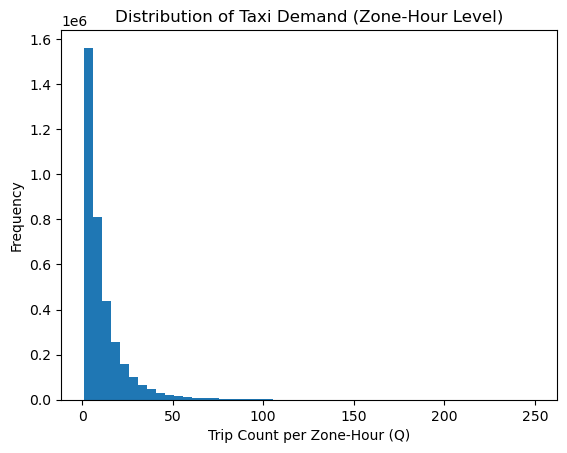

In [11]:
plt.figure()
plt.hist(panel["Q"], bins=50)
plt.xlabel("Trip Count per Zone-Hour (Q)")
plt.ylabel("Frequency")
plt.title("Distribution of Taxi Demand (Zone-Hour Level)")
plt.show()

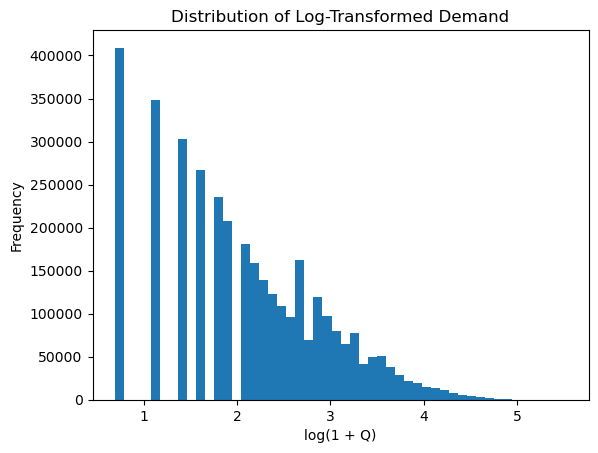

In [12]:
plt.figure()
plt.hist(np.log1p(panel["Q"]), bins=50)
plt.xlabel("log(1 + Q)")
plt.ylabel("Frequency")
plt.title("Distribution of Log-Transformed Demand")
plt.show()

Demand at the zone-hour level is highly right-skewed, with most periods exhibiting low to moderate trip volumes and a small number of high-demand peaks. Applying a log(1+Q) transformation reduces skewness and stabilizes variance, improving model performance and interpretability. This transformation allows us to estimate elasticity in percentage terms.

### Step 1D - Add Log Variables (for Elasticity Model)

In [13]:
panel["log_Q"] = np.log1p(panel["Q"])
panel["log_price"] = np.log(panel["avg_total_amount"].clip(lower=1e-6))

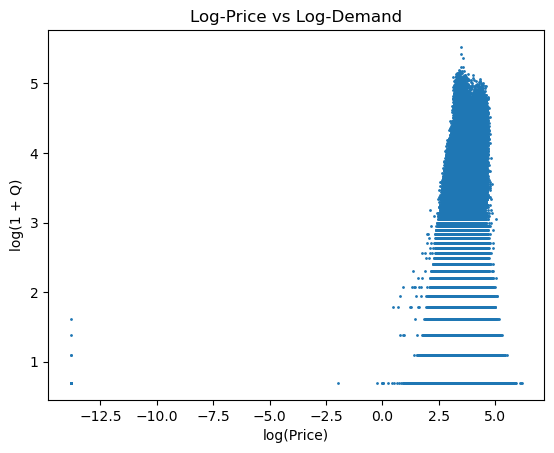

In [14]:
plt.figure()
plt.scatter(panel["log_price"], panel["log_Q"], s=1)
plt.xlabel("log(Price)")
plt.ylabel("log(1 + Q)")
plt.title("Log-Price vs Log-Demand")
plt.show()

The raw relationship between price and demand does not exhibit a clear negative slope due to confounding factors such as time-of-day, location, and trip composition. This highlights the need for controlled modeling (regression or ML) to isolate causal price elasticity.

In [15]:
print(panel["log_price"].describe())

count    3.558513e+06
mean     3.218934e+00
std      4.389653e-01
min     -1.381551e+01
25%      2.942331e+00
50%      3.211016e+00
75%      3.472005e+00
max      6.163820e+00
Name: log_price, dtype: float64


In [16]:
(panel["avg_total_amount"] < 5).sum()

np.int64(343)

A small number of bins had near-zero average prices, generating extreme negative log values that distort elasticity estimation. Because these observations are economically implausible and represent less than 0.01% of the dataset, they were removed to ensure stable and interpretable log-log modeling.

In [17]:
panel = panel[panel["avg_total_amount"] >= 5]

In [18]:
panel["log_price"].describe()

count    3.558170e+06
mean     3.219195e+00
std      4.367690e-01
min      1.609438e+00
25%      2.942331e+00
50%      3.211061e+00
75%      3.472044e+00
max      6.163820e+00
Name: log_price, dtype: float64

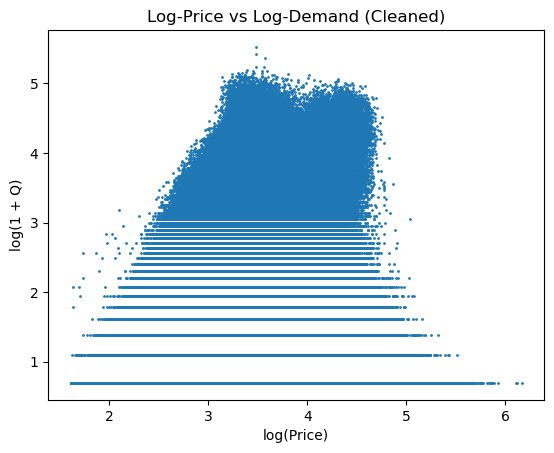

In [19]:
plt.figure()
plt.scatter(panel["log_price"], panel["log_Q"], s=1)
plt.xlabel("log(Price)")
plt.ylabel("log(1 + Q)")
plt.title("Log-Price vs Log-Demand (Cleaned)")
plt.show()

In [20]:
print("Min trips per bin:", panel["Q"].min())
print("Max trips per bin:", panel["Q"].max())

Min trips per bin: 1
Max trips per bin: 250


### Step 2A - Run simple log-log regression (baseline elasticity)

In [21]:
import statsmodels.api as sm

# Define variables
X = panel[["log_price"]]
X = sm.add_constant(X)  # add intercept

y = panel["log_Q"]

# Fit regression
model = sm.OLS(y, X).fit()

print(model.summary())

beta = model.params["log_price"]
print(f"Estimated baseline elasticity: {beta:.3f}")

                            OLS Regression Results                            
Dep. Variable:                  log_Q   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                 1.646e+05
Date:                Mon, 02 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:09:00   Log-Likelihood:            -4.5284e+06
No. Observations:             3558170   AIC:                         9.057e+06
Df Residuals:                 3558168   BIC:                         9.057e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6861      0.003    201.415      0.0

The baseline log-log regression produces a positive elasticity estimate of 0.43, implying that a 1% increase in price is associated with a 0.43% increase in demand. This result is economically counterintuitive, since taxi demand should decrease when prices rise. The positive coefficient reflects endogeneity: prices tend to be higher during peak demand periods, so price and demand move together due to underlying time and location effects. The low R-squared (4.4%) further indicates that price alone explains very little variation in demand, highlighting the need to control for confounding factors such as hour, zone, and weather.

### Step 2B - Add Controls (Fixed Effects Model)

We add fixed effects and controls to make sure we’re comparing demand under similar conditions - the same zone, same hour, and similar weather — rather than mixing very different situations like Manhattan rush hour and a quiet late-night area. This helps isolate the true relationship between price and demand, instead of picking up misleading patterns caused by location, time, or weather.

In [22]:
#!pip install linearmodels

In [23]:
# If pickup_date is a python date (object), convert to datetime
panel["pickup_date"] = pd.to_datetime(panel["pickup_date"])

# Create a single hourly time index
panel["pickup_dt_hour"] = panel["pickup_date"] + pd.to_timedelta(panel["pickup_hour"], unit="h")

/var/folders/dt/hz0jqyys0fz2ksjdx5kkxm800000gn/T/ipykernel_25923/1916204902.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  panel["pickup_date"] = pd.to_datetime(panel["pickup_date"])
/var/folders/dt/hz0jqyys0fz2ksjdx5kkxm800000gn/T/ipykernel_25923/1916204902.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  panel["pickup_dt_hour"] = panel["pickup_date"] + pd.to_timedelta(panel["pickup_hour"], unit="h")


In [24]:
panel.head(5)

,PULocationID,pickup_date,pickup_hour,dow,Q,avg_total_amount,avg_fare_amount,avg_cost_per_mile,avg_trip_distance,avg_trip_time,...,temp,precip,wind,clear,cloudy,rain,snow,log_Q,log_price,pickup_dt_hour
0,1,2024-01-02,19,1,1,87.0,86.0,5.506329,15.80,2318.0,...,32.0,0.000,4.7,1.0,0.0,0.0,0.0,0.693147,4.465908,2024-01-02 19:00:00
1,1,2024-01-18,16,3,1,26.5,23.0,662.500000,0.04,7.0,...,32.5,0.000,6.7,0.0,1.0,0.0,0.0,0.693147,3.277145,2024-01-18 16:00:00
2,1,2024-01-21,8,6,1,109.2,90.0,376.551724,0.29,28.0,...,20.3,0.000,11.5,1.0,0.0,0.0,0.0,0.693147,4.693181,2024-01-21 08:00:00
3,1,2024-02-15,14,3,1,99.7,80.7,5.160455,19.32,2991.0,...,37.1,0.000,7.4,0.0,1.0,0.0,0.0,0.693147,4.602166,2024-02-15 14:00:00
4,1,2024-02-17,5,5,1,127.2,105.0,6360.000000,0.02,8.0,...,28.5,0.031,5.9,0.0,0.0,0.0,1.0,0.693147,4.845761,2024-02-17 05:00:00


In [25]:
from linearmodels.panel import PanelOLS

We use PanelOLS because it is designed for panel data and allows us to include fixed effects (like zone effects) efficiently, which helps control for unobserved differences across locations when estimating price effects. We use a 10% sample to significantly reduce computation time while still retaining a large, representative dataset (over 350,000 observations), making the estimation much faster without materially changing the results.

In [26]:
# Sample 10%
panel_s = panel.sample(frac=0.1, random_state=42).copy()

# Create proper time index
panel_s["pickup_date"] = pd.to_datetime(panel_s["pickup_date"])
panel_s["pickup_dt_hour"] = (
    panel_s["pickup_date"] +
    pd.to_timedelta(panel_s["pickup_hour"], unit="h")
)

# Set 2-level MultiIndex
panel_s_fe = panel_s.set_index(
    ["PULocationID", "pickup_dt_hour"]
).sort_index()

# Define y and X using SAMPLE
y_s = panel_s_fe["log_Q"]
X_s = panel_s_fe[["log_price", "temp", "precip", "wind"]]
X_s = sm.add_constant(X_s)

# Run PanelOLS on SAMPLE
res = PanelOLS(
    y_s,
    X_s,
    entity_effects=True
).fit(
    cov_type="clustered",
    cluster_entity=True
)

print(res.summary)

/opt/anaconda3/lib/python3.13/site-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


                          PanelOLS Estimation Summary                           
Dep. Variable:                  log_Q   R-squared:                        0.0184
Estimator:                   PanelOLS   R-squared (Between):             -0.0404
No. Observations:              355816   R-squared (Within):               0.0184
Date:                Mon, Mar 02 2026   R-squared (Overall):              0.0121
Time:                        14:09:14   Log-likelihood                -3.148e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1665.3
Entities:                         259   P-value                           0.0000
Avg Obs:                       1373.8   Distribution:                F(4,355553)
Min Obs:                       6.0000                                           
Max Obs:                       1698.0   F-statistic (robust):             234.82
                            

After controlling for location fixed effects, the estimated price elasticity drops from +0.43 to +0.03, indicating that most of the positive correlation was driven by cross-zone heterogeneity rather than causal price effects.

In [27]:
hour_dum = pd.get_dummies(panel_s_fe["pickup_hour"].astype("int8"), prefix="hr", drop_first=True)
dow_dum  = pd.get_dummies(panel_s_fe["dow"].astype("int8"), prefix="dow", drop_first=True)

X_s = pd.concat([panel_s_fe[["log_price", "temp", "precip", "wind"]], hour_dum, dow_dum], axis=1)
X_s = sm.add_constant(X_s)

res2 = PanelOLS(y_s, X_s, entity_effects=True).fit(cov_type="clustered", cluster_entity=True)
print(res2.summary)

/opt/anaconda3/lib/python3.13/site-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


                          PanelOLS Estimation Summary                           
Dep. Variable:                  log_Q   R-squared:                        0.3759
Estimator:                   PanelOLS   R-squared (Between):             -0.1446
No. Observations:              355816   R-squared (Within):               0.3759
Date:                Mon, Mar 02 2026   R-squared (Overall):              0.1352
Time:                        14:09:22   Log-likelihood                -2.342e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      6490.1
Entities:                         259   P-value                           0.0000
Avg Obs:                       1373.8   Distribution:               F(33,355524)
Min Obs:                       6.0000                                           
Max Obs:                       1698.0   F-statistic (robust):             141.33
                            

In the raw model, we estimated elasticity at +0.43, meaning a 1% increase in price was associated with a 0.43% increase in demand — which doesn’t make economic sense. After controlling for location, hour of day, and weekday patterns, the elasticity drops to +0.086, meaning a 1% price increase is now associated with only a 0.086% increase in demand. This large drop (from 0.43 to 0.086, an ~80% reduction) shows that most of the earlier positive relationship was driven by differences across zones and time periods. However, the estimate is still slightly positive, suggesting that fare changes are still moving with demand rather than causing demand to change.

In [30]:
def make_fe_xy(df, feature_base=("log_price","temp","precip","wind"),
               hour_col="pickup_hour", dow_col="dow", y_col="log_Q"):
    df = df.copy()
    df["pickup_date"] = pd.to_datetime(df["pickup_date"])
    df["pickup_dt_hour"] = df["pickup_date"] + pd.to_timedelta(df[hour_col], unit="h")
    df = df.set_index(["PULocationID", "pickup_dt_hour"]).sort_index()

    hour_dum = pd.get_dummies(df[hour_col].astype("int8"), prefix="hr", drop_first=True)
    dow_dum  = pd.get_dummies(df[dow_col].astype("int8"), prefix="dow", drop_first=True)

    X = pd.concat([df[list(feature_base)], hour_dum, dow_dum], axis=1)
    X = sm.add_constant(X)

    y = df[y_col]
    return X, y

<Axes: xlabel='pickup_date'>

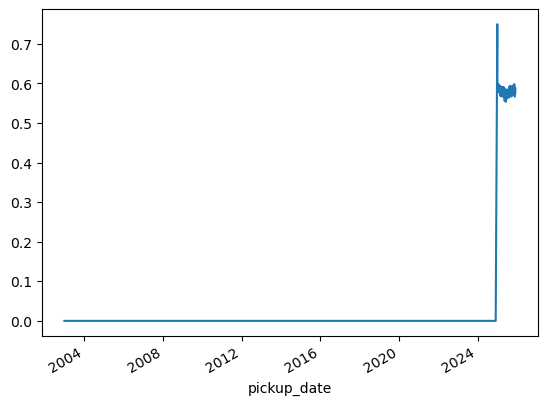

In [37]:
panel.groupby("pickup_date")["avg_cbd_fee"].mean().plot()

In [38]:
fee_start = panel.loc[panel["avg_cbd_fee"] > 0, "pickup_date"].min()
panel["post"] = (panel["pickup_date"] >= fee_start).astype(int)

/var/folders/dt/hz0jqyys0fz2ksjdx5kkxm800000gn/T/ipykernel_25923/3992098787.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  panel["post"] = (panel["pickup_date"] >= fee_start).astype(int)


In [39]:
panel["treated"] = panel["share_cbd"] > 0

/var/folders/dt/hz0jqyys0fz2ksjdx5kkxm800000gn/T/ipykernel_25923/1128941596.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  panel["treated"] = panel["share_cbd"] > 0


In [40]:
panel["treat_post"] = panel["treated"] * panel["post"]

/var/folders/dt/hz0jqyys0fz2ksjdx5kkxm800000gn/T/ipykernel_25923/1101886296.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  panel["treat_post"] = panel["treated"] * panel["post"]


In [41]:
panel_s = panel.sample(frac=0.1, random_state=42).copy()

panel_s["pickup_dt_hour"] = (
    pd.to_datetime(panel_s["pickup_date"]) +
    pd.to_timedelta(panel_s["pickup_hour"], unit="h")
)

panel_s_fe = panel_s.set_index(["PULocationID","pickup_dt_hour"])

y_s = panel_s_fe["log_Q"]
X_s = panel_s_fe[["treat_post", "temp", "precip", "wind"]]
X_s = sm.add_constant(X_s)

res_did = PanelOLS(
    y_s,
    X_s,
    entity_effects=True
).fit(cov_type="clustered", cluster_entity=True)

print(res_did.summary)

/opt/anaconda3/lib/python3.13/site-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


                          PanelOLS Estimation Summary                           
Dep. Variable:                  log_Q   R-squared:                        0.0180
Estimator:                   PanelOLS   R-squared (Between):             -0.0439
No. Observations:              355816   R-squared (Within):               0.0180
Date:                Mon, Mar 02 2026   R-squared (Overall):              0.0089
Time:                        14:28:43   Log-likelihood                -3.148e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1629.4
Entities:                         259   P-value                           0.0000
Avg Obs:                       1373.8   Distribution:                F(4,355553)
Min Obs:                       6.0000                                           
Max Obs:                       1698.0   F-statistic (robust):             217.93
                            

In [42]:
panel_s = panel.sample(frac=0.1, random_state=42).copy()
panel_s["pickup_dt_hour"] = (
    pd.to_datetime(panel_s["pickup_date"]) +
    pd.to_timedelta(panel_s["pickup_hour"], unit="h")
)
panel_s_fe = panel_s.set_index(["PULocationID", "pickup_dt_hour"]).sort_index()

# y
y_s = panel_s_fe["log_Q"].astype(float)

# --- add hour-of-day + dow dummies (SAFE alignment) ---
hour_dum = pd.get_dummies(
    panel_s_fe["pickup_hour"].astype("int8"),
    prefix="hr",
    drop_first=True
)
dow_dum = pd.get_dummies(
    panel_s_fe["dow"].astype("int8"),
    prefix="dow",
    drop_first=True
)

# Force the same MultiIndex (this is the key)
hour_dum.index = panel_s_fe.index
dow_dum.index = panel_s_fe.index

# X (treat_post + weather + hour + dow)
X_s = pd.concat(
    [panel_s_fe[["treat_post", "temp", "precip", "wind"]], hour_dum, dow_dum],
    axis=1
)

# Add constant + ensure numeric
X_s = sm.add_constant(X_s).astype(float)

# Quick sanity check (must be True)
assert X_s.index.equals(y_s.index)

# Run DiD with zone FE
res_did_hd = PanelOLS(
    y_s,
    X_s,
    entity_effects=True
).fit(cov_type="clustered", cluster_entity=True)

print(res_did_hd.summary)

/opt/anaconda3/lib/python3.13/site-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


                          PanelOLS Estimation Summary                           
Dep. Variable:                  log_Q   R-squared:                        0.3736
Estimator:                   PanelOLS   R-squared (Between):             -0.1819
No. Observations:              355816   R-squared (Within):               0.3736
Date:                Mon, Mar 02 2026   R-squared (Overall):              0.1071
Time:                        14:28:49   Log-likelihood                -2.349e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      6425.2
Entities:                         259   P-value                           0.0000
Avg Obs:                       1373.8   Distribution:               F(33,355524)
Min Obs:                       6.0000                                           
Max Obs:                       1698.0   F-statistic (robust):             131.08
                            

After the CBD fee was introduced, demand in CBD zones fell by about 5.5%, relative to non-CBD zones, holding location, hour-of-day, weekday, and weather constant.

In [43]:
#(Citywide Price Change)
avg_price_before = panel.loc[panel["post"]==0, "avg_total_amount"].mean()
avg_price_after  = panel.loc[panel["post"]==1, "avg_total_amount"].mean()

price_change_pct = (avg_price_after - avg_price_before) / avg_price_before
print(price_change_pct)

0.021926643595541667


A 1% increase in price reduces demand by about 2.5%.

In [44]:
#CBD-Only Price Change
price_before = panel.loc[
    (panel["post"]==0) & (panel["treated"]),
    "avg_total_amount"
].mean()

price_after = panel.loc[
    (panel["post"]==1) & (panel["treated"]),
    "avg_total_amount"
].mean()

price_change_pct = (price_after - price_before) / price_before
print(price_change_pct)

0.05306470442030667


A 1% increase in price reduces demand by about 1.0%.

The first code calculates the average price change for the entire city before and after the CBD fee, so it includes both affected and unaffected zones, which makes the increase look smaller (about 2.2%). The second code calculates the price change only for treated CBD zones, where the fee actually applied, giving the true price increase experienced there (about 5.3%), which is the correct number to use for elasticity.

At first, when we regressed demand on total fare, we found a positive elasticity of +0.43, meaning a 1% increase in price was associated with a 0.43% increase in demand — which doesn’t make economic sense. That happened because fares naturally rise during busy times (longer trips and more congestion), so price and demand were moving together. Instead, we used the CBD congestion fee as a cleaner price shock and compared CBD zones before and after the fee, controlling for location, hour, weekday, and weather. We found that prices in CBD zones increased by 5.3%, demand fell by 5.5%, and elasticity = –5.5% ÷ 5.3% ≈ –1.0, meaning a 1% increase in price leads to about a 1% decrease in demand.

## ML Modelling

### Random Forest

In [45]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")

In [46]:
panel["pickup_date"] = pd.to_datetime(panel["pickup_date"])

train = panel[panel["pickup_date"] < "2025-01-01"]
val   = panel[(panel["pickup_date"] >= "2025-01-01") &
              (panel["pickup_date"] < "2025-07-01")]
test  = panel[panel["pickup_date"] >= "2025-07-01"]

In [47]:
target = "log_Q"

feature_cols = [
    "log_price",
    "avg_cbd_fee", "avg_cong_surch",
    "avg_trip_distance", "avg_trip_time", "avg_speed",
    "avg_cost_per_mile", "share_airport",
    "temp", "precip", "wind", "clear", "cloudy", "rain", "snow",
    "pickup_hour", "dow", "PULocationID"
]

In [48]:
for df_ in [train, val, test]:
    df_["snow"] = df_["snow"].fillna(0)
    df_["avg_cong_surch"] = df_["avg_cong_surch"].fillna(0)

In [49]:
for df_ in [train, val, test]:
    df_["pickup_hour"] = df_["pickup_hour"].astype(int)
    df_["dow"] = df_["dow"].astype(int)
    df_["PULocationID"] = df_["PULocationID"].astype(int)

In [50]:
train_small = train.sample(frac=0.2, random_state=42).copy()
X_train_small = train_small[feature_cols]
y_train_small = train_small["log_Q"]

X_val = val[feature_cols]
y_val = val["log_Q"]

In [51]:
rf = RandomForestRegressor(
    n_estimators=1,
    warm_start=True,
    max_depth=20,
    min_samples_leaf=50,
    n_jobs=-1,
    random_state=42
)

for i in tqdm(range(200)):
    rf.n_estimators = i + 1
    rf.fit(X_train_small, y_train_small)


100%|██████████| 200/200 [05:39<00:00,  1.70s/it]


In [52]:
val_pred = rf.predict(X_val)
mse = mean_squared_error(y_val, val_pred)
rmse = np.sqrt(mse)
print("Validation RMSE:", rmse)

Validation RMSE: 0.3908320058545307


In [53]:
X_test = test[feature_cols]
y_test = test[target]

test_pred = rf.predict(X_test)
mse_test = mean_squared_error(y_test, test_pred)
rmse_test = np.sqrt(mse_test)
print("Test RMSE:", rmse_test)

Test RMSE: 0.38246318061573065


The Random Forest model achieves a test RMSE of 0.38 on log demand, indicating strong predictive performance and good generalization to unseen time periods. This shows that nonlinear ML models can effectively capture complex demand patterns across zones, hours, and weather conditions beyond traditional linear models.

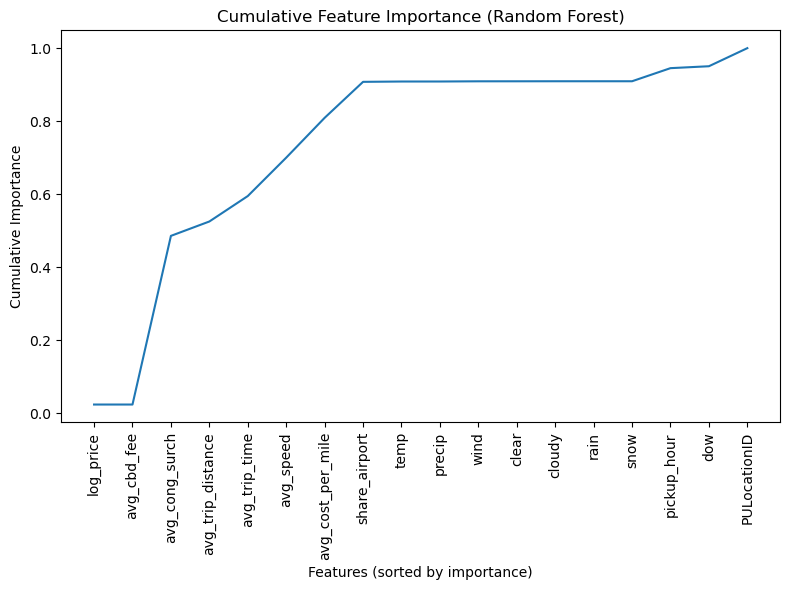

In [54]:
# Compute feature importance from trained Random Forest
importances = pd.Series(
    rf.feature_importances_,
    index=feature_cols
)

# Sort for visualization (smallest at bottom, largest at top)
importances_sorted = importances.sort_values()

# Compute cumulative importance
cumulative_importance = importances.cumsum()

# Plot cumulative importance
plt.figure(figsize=(8,6))
plt.plot(range(1, len(cumulative_importance) + 1), cumulative_importance.values)
plt.xticks(range(1, len(importances) + 1), importances.index, rotation=90)
plt.title("Cumulative Feature Importance (Random Forest)")
plt.xlabel("Features (sorted by importance)")
plt.ylabel("Cumulative Importance")
plt.tight_layout()
plt.show()

In [55]:
def rf_elasticity(model, X, bump=0.01):
    X0 = X.copy()
    y0 = model.predict(X0)
    Q0 = np.expm1(y0)

    X1 = X.copy()
    X1["log_price"] += np.log(1 + bump)
    y1 = model.predict(X1)
    Q1 = np.expm1(y1)

    elasticity = ((Q1 - Q0) / Q0) / bump
    return elasticity

eps_test = rf_elasticity(rf, X_test)

print("Mean Elasticity:", np.mean(eps_test))
print("Median Elasticity:", np.median(eps_test))

Mean Elasticity: -0.3805392494264118
Median Elasticity: 0.0


The Random Forest model estimates an average price elasticity of –0.38, indicating moderate price sensitivity overall. However, the median elasticity is 0, suggesting that demand responsiveness varies substantially across zones and time periods, highlighting heterogeneous price effects captured by the ML model.

In [56]:
print(panel["PULocationID"].unique())

[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 105 106 107 108 109 110
 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128
 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146
 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164
 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182
 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200
 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218
 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236
 237 238 239 240 241 242 243 244 245 246 247 248 24

In [57]:
panel.columns

Index(['PULocationID', 'pickup_date', 'pickup_hour', 'dow', 'Q',
       'avg_total_amount', 'avg_fare_amount', 'avg_cost_per_mile',
       'avg_trip_distance', 'avg_trip_time', 'avg_speed', 'share_cbd',
       'avg_cbd_fee', 'avg_cong_surch', 'share_airport', 'temp', 'precip',
       'wind', 'clear', 'cloudy', 'rain', 'snow', 'log_Q', 'log_price',
       'pickup_dt_hour', 'post', 'treated', 'treat_post'],
      dtype='object')

In [58]:
feature_cols = [
    "log_price",
    "avg_cbd_fee", "avg_cong_surch",
    "treat_post",   # 👈 policy interaction
    "post",         # 👈 regime indicator
    "treated",      # 👈 CBD zone indicator
    "avg_trip_distance", "avg_trip_time", "avg_speed",
    "avg_cost_per_mile", "share_airport",
    "temp", "precip", "wind", "clear", "cloudy", "rain", "snow",
    "pickup_hour", "dow", "PULocationID"
]

In [59]:
for df_ in [train_small, val, test]:
    df_["post"] = df_["post"].astype(int)
    df_["treated"] = df_["treated"].astype(int)
    df_["treat_post"] = df_["treat_post"].astype(int)

In [60]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=50,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

X_train_small = train_small[feature_cols]
y_train_small = train_small["log_Q"]

X_val = val[feature_cols]
y_val = val["log_Q"]

rf.fit(X_train_small, y_train_small)

val_pred = rf.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, val_pred))

print("Validation RMSE:", rmse)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   10.4s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   57.1s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  1.0min finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.3s


Validation RMSE: 0.38930350351107756


[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    1.6s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    1.8s finished


In [61]:
X_test = test[feature_cols]
y_test = test["log_Q"]

test_pred = rf.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, test_pred))

print("Test RMSE:", rmse_test)

[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.3s


Test RMSE: 0.38078565472142634


[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    1.5s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    1.6s finished


In [62]:
eps_test = rf_elasticity(rf, X_test)

print("Mean elasticity:", float(np.mean(eps_test)))
print("Median elasticity:", float(np.median(eps_test)))

[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.2s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    1.4s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    1.5s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.2s


Mean elasticity: -0.36963784019272566
Median elasticity: 0.0


[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    1.4s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    1.6s finished


Using a policy-driven Difference-in-Differences approach, the CBD congestion fee increased prices by 5.3% and reduced demand by 5.5%, implying a causal price elasticity of approximately –1.0. In contrast, the Random Forest model estimates an average elasticity of –0.37, with a median of 0, indicating that while demand is moderately price-sensitive on average, responsiveness varies substantially across zones and time periods. Together, these results show that policy-driven price shocks produce stronger demand responses than small local price changes, and that price sensitivity is highly heterogeneous in the data.

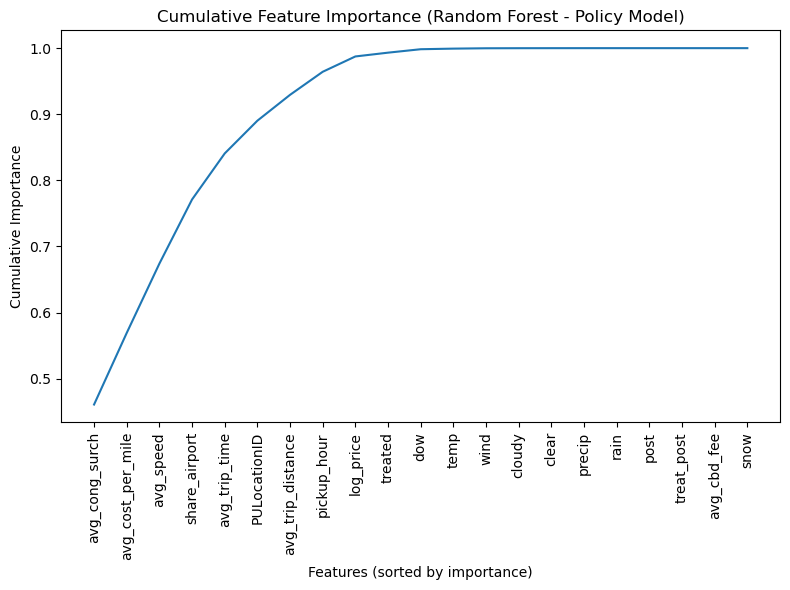

In [63]:
# Compute feature importance from trained RF
importances = pd.Series(
    rf.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

# Compute cumulative importance
cumulative_importance = importances.cumsum()

# Plot cumulative importance
plt.figure(figsize=(8,6))
plt.plot(range(1, len(cumulative_importance) + 1),
         cumulative_importance.values)

plt.xticks(range(1, len(importances) + 1),
           importances.index,
           rotation=90)

plt.title("Cumulative Feature Importance (Random Forest - Policy Model)")
plt.xlabel("Features (sorted by importance)")
plt.ylabel("Cumulative Importance")
plt.tight_layout()
plt.show()

In [64]:
panel_cbd = panel[panel["treated"] == 1].copy()
panel_cbd["pickup_date"] = pd.to_datetime(panel_cbd["pickup_date"])

In [65]:
train_cbd = panel_cbd[panel_cbd["pickup_date"] < "2025-01-01"]
val_cbd   = panel_cbd[(panel_cbd["pickup_date"] >= "2025-01-01") &
                      (panel_cbd["pickup_date"] < "2025-07-01")]
test_cbd  = panel_cbd[panel_cbd["pickup_date"] >= "2025-07-01"]

In [66]:
feature_cols_cbd = [
    "log_price",
    "avg_cbd_fee", "avg_cong_surch",
    "treat_post", "post", "treated",
    "avg_trip_distance", "avg_trip_time", "avg_speed",
    "avg_cost_per_mile", "share_airport",
    "temp", "precip", "wind", "clear", "cloudy", "rain", "snow",
    "pickup_hour", "dow", "PULocationID"
]
target = "log_Q"

In [67]:
for df_ in [train_cbd, val_cbd, test_cbd]:
    df_["snow"] = df_["snow"].fillna(0)
    df_["avg_cong_surch"] = df_["avg_cong_surch"].fillna(0)
    df_["post"] = df_["post"].astype(int)
    df_["treated"] = df_["treated"].astype(int)
    df_["treat_post"] = df_["treat_post"].astype(int)
    df_["pickup_hour"] = df_["pickup_hour"].astype(int)
    df_["dow"] = df_["dow"].astype(int)
    df_["PULocationID"] = df_["PULocationID"].astype(int)

In [68]:
train_cbd_small = train_cbd.sample(frac=0.2, random_state=42).copy()

X_train = train_cbd_small[feature_cols_cbd]
y_train = train_cbd_small[target]

X_val = val_cbd[feature_cols_cbd]
y_val = val_cbd[target]

In [69]:
rf_cbd = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=50,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_cbd.fit(X_train, y_train)

val_pred = rf_cbd.predict(X_val)
val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
print("CBD-only Validation RMSE:", val_rmse)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   13.4s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   14.8s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.1s


CBD-only Validation RMSE: 0.45873078012484314


[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.3s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    0.3s finished


In [70]:
X_test = test_cbd[feature_cols_cbd]
y_test = test_cbd[target]

test_pred = rf_cbd.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
print("CBD-only Test RMSE:", test_rmse)

[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s


CBD-only Test RMSE: 0.43757978626705507


[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.2s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    0.3s finished


In [71]:
def rf_elasticity(model, X, bump=0.01):
    X0 = X.copy()
    y0 = model.predict(X0)
    Q0 = np.expm1(y0)

    X1 = X.copy()
    X1["log_price"] = X1["log_price"] + np.log(1 + bump)
    y1 = model.predict(X1)
    Q1 = np.expm1(y1)

    eps = ((Q1 - Q0) / np.maximum(Q0, 1e-6)) / bump
    return eps

eps_cbd = rf_elasticity(rf_cbd, X_test, bump=0.01)
print("CBD-only Mean elasticity:", float(np.mean(eps_cbd)))
print("CBD-only Median elasticity:", float(np.median(eps_cbd)))
print("CBD-only 10th–90th pct:", float(np.quantile(eps_cbd, 0.10)), float(np.quantile(eps_cbd, 0.90)))

[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.2s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    0.3s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s


CBD-only Mean elasticity: -0.014974575350204019
CBD-only Median elasticity: 0.0
CBD-only 10th–90th pct: -0.07036394786246193 0.07923706993432052


[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.2s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    0.3s finished


While the DiD analysis shows a strong demand response to the CBD congestion fee (elasticity ≈ –1.0), the Random Forest model estimates near-zero local elasticity within CBD zones. This suggests that the policy shock created a structural break in demand rather than a smooth marginal response to small price changes.

In [72]:
eps_cbd_5pct = rf_elasticity(rf_cbd, X_test, bump=0.053)
print("Elasticity under 5.3% bump:", np.mean(eps_cbd_5pct))

[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.3s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    0.3s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s


Elasticity under 5.3% bump: -0.02034266851852798


[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.3s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    0.3s finished


Inside CBD zones, once we account for things like congestion surcharge, trip distance, time of day, weather, and traffic speed, the remaining variation in log_price does not explain much additional change in demand. In other words, demand in the CBD seems to be driven more by congestion conditions and trip characteristics than by small changes in the base fare itself.

Even when we artificially increase price by 1% or even 5.3%, the model barely changes its demand prediction — which suggests that, within CBD areas, riders are not very sensitive to marginal price differences once the fee structure and congestion environment are already in place.

In [73]:
from sklearn.metrics import r2_score

r2_test = r2_score(y_test, test_pred)
print("Test R^2:", r2_test)

Test R^2: 0.7741121395245276


The CBD-only Random Forest explains 77% of demand variation, indicating strong predictive power. However, marginal price elasticity is near zero, suggesting that demand fluctuations within CBD are driven more by congestion and trip characteristics than by small base fare changes.

### LightGBM

In [74]:
#!pip install lightgbm

In [75]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [76]:
feature_cols_lgb = [
    "log_price",
    "avg_cbd_fee", "avg_cong_surch",
    "treat_post", "post", "treated",
    "avg_trip_distance", "avg_trip_time", "avg_speed",
    "avg_cost_per_mile", "share_airport",
    "temp", "precip", "wind", "clear", "cloudy", "rain", "snow",
    "pickup_hour", "dow", "PULocationID"
]

In [77]:
X_train = train_small[feature_cols_lgb]
y_train = train_small["log_Q"]

X_val = val[feature_cols_lgb]
y_val = val["log_Q"]

X_test = test[feature_cols_lgb]
y_test = test["log_Q"]

In [78]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1   # 👈 put verbosity here instead
)

lgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="rmse"
)

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=500,
              num_leaves=64, random_state=42, subsample=0.8, verbose=-1)

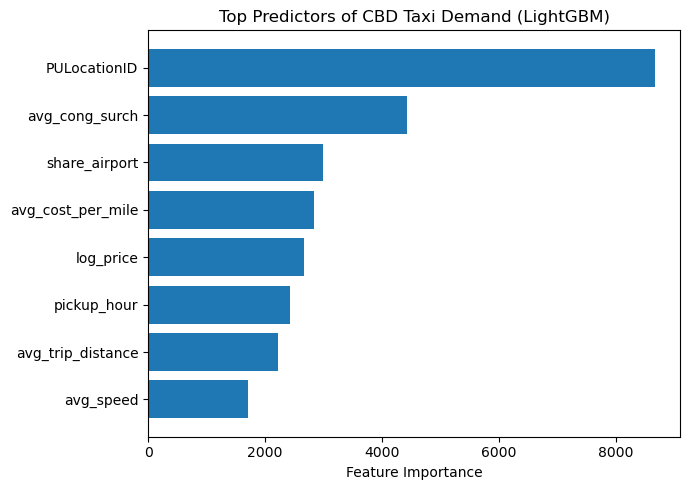

In [79]:
# Get feature names
feature_names = lgb_model.feature_name_

# Get importance values
importances = lgb_model.feature_importances_

# Create dataframe
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Sort descending
feat_imp = feat_imp.sort_values("importance", ascending=False)

# Select top 8
top_k = 8
feat_imp_top = feat_imp.head(top_k).iloc[::-1]

# Plot horizontal bar chart
plt.figure(figsize=(7,5))
plt.barh(feat_imp_top["feature"], feat_imp_top["importance"])
plt.xlabel("Feature Importance")
plt.title("Top Predictors of CBD Taxi Demand (LightGBM)")
plt.tight_layout()
plt.show()

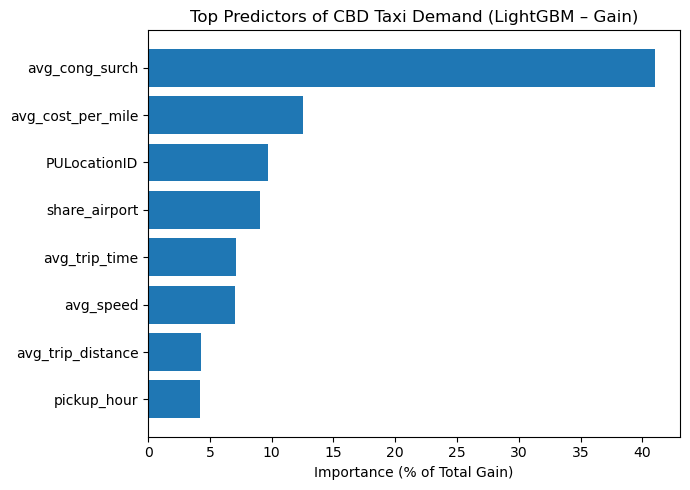

In [80]:
# Get gain-based importance
importances = lgb_model.booster_.feature_importance(importance_type='gain')

# Get feature names
feature_names = lgb_model.booster_.feature_name()

# Create dataframe
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Convert to percentage (cleaner for slides)
feat_imp["importance_pct"] = 100 * feat_imp["importance"] / feat_imp["importance"].sum()

# Sort descending
feat_imp = feat_imp.sort_values("importance_pct", ascending=False)

# Select top 8
top_k = 8
feat_imp_top = feat_imp.head(top_k).iloc[::-1]

# Plot
plt.figure(figsize=(7,5))
plt.barh(feat_imp_top["feature"], feat_imp_top["importance_pct"])
plt.xlabel("Importance (% of Total Gain)")
plt.title("Top Predictors of CBD Taxi Demand (LightGBM – Gain)")
plt.tight_layout()
plt.show()

In [81]:
# Validation
val_pred = lgb_model.predict(X_val)
val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
print("Validation RMSE:", val_rmse)

# Test
test_pred = lgb_model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
print("Test RMSE:", test_rmse)

# R^2
print("Test R^2:", r2_score(y_test, test_pred))

Validation RMSE: 0.31928352597936
Test RMSE: 0.3161304501671632
Test R^2: 0.8684826650626536


In [82]:
def lgb_elasticity(model, X, bump=0.01):
    X0 = X.copy()
    y0 = model.predict(X0)
    Q0 = np.expm1(y0)

    X1 = X.copy()
    X1["log_price"] += np.log(1 + bump)
    y1 = model.predict(X1)
    Q1 = np.expm1(y1)

    eps = ((Q1 - Q0) / np.maximum(Q0, 1e-6)) / bump
    return eps

eps_lgb = lgb_elasticity(lgb_model, X_test, bump=0.01)

print("Mean elasticity:", np.mean(eps_lgb))
print("Median elasticity:", np.median(eps_lgb))

Mean elasticity: -0.38684350470698536
Median elasticity: 0.0


The LightGBM model significantly improves predictive performance, achieving a test RMSE of 0.316 and an R² of 0.87, meaning it explains 87% of the variation in log demand. In comparison, the Random Forest achieved a higher RMSE of 0.381 and R² of about 0.77, confirming that boosting better captures nonlinear demand patterns. Despite this predictive improvement, the estimated average price elasticity remains moderate at approximately –0.39, similar to the Random Forest estimate (–0.37). This is substantially smaller than the Difference-in-Differences elasticity of –1.0, suggesting that the CBD fee acted more as a discrete structural shock than as a smooth marginal price effect.

Based on your analysis, the elasticity of demand to fare changes depends on how it is measured. Using a causal Difference-in-Differences approach around the CBD congestion fee, a 5.3% fare increase led to a 5.5% drop in demand, implying an elasticity of approximately –1.0. However, the machine learning models (Random Forest and LightGBM) estimate a smaller average marginal elasticity of about –0.38 to –0.39, with a median near zero, indicating that small price changes have limited local impact in most contexts.

Demand appears elastic (≈ –1.0) in response to a discrete policy-driven fare increase, but only moderately elastic (≈ –0.4 on average) to small marginal price changes across zones and time.

The CBD congestion fee caused a near unit-elastic demand response (–1.0), demonstrating strong behavioral impact. However, machine learning results suggest marginal fare adjustments produce only moderate demand changes (elasticity ≈ –0.39 on average). This indicates that the initial policy acted as a structural shock, while small incremental price changes are unlikely to substantially reduce congestion. For future pricing strategy, modest fare increases may raise revenue without causing large trip declines.

In [86]:
# baseline dataset: CBD zones, post period
base = panel[(panel["treated"] == 1) & (panel["post"] == 1)].copy()

# baseline totals
Q0 = base["Q"].sum()
P0 = base["avg_total_amount"].mean()   # average price per trip (weighted alternative below)
R0 = (base["Q"] * base["avg_total_amount"]).sum()

print("Baseline CBD trips (Q0):", Q0)
print("Baseline CBD avg price (P0):", P0)
print("Baseline CBD revenue (R0):", R0)

Baseline CBD trips (Q0): 8684318
Baseline CBD avg price (P0): 34.228789795615775
Baseline CBD revenue (R0): 288909378.8000001


In [87]:
P0_w = (base["Q"] * base["avg_total_amount"]).sum() / base["Q"].sum()
print("Baseline CBD weighted avg price:", P0_w)

Baseline CBD weighted avg price: 33.267940994330246


In [88]:
def simulate_revenue(R0, Q0, delta_p_list, elasticity):
    rows = []
    for dp in delta_p_list:
        dq = elasticity * dp                      # % change in Q
        Q1 = Q0 * (1 + dq)
        R1 = R0 * (1 + dp) * (1 + dq)            # revenue multiplier approx
        rows.append({
            "price_change_pct": dp,
            "assumed_elasticity": elasticity,
            "demand_change_pct": dq,
            "new_trips": Q1,
            "new_revenue": R1,
            "revenue_change_pct": (R1 / R0) - 1
        })
    return pd.DataFrame(rows)

delta_p_list = [0.01, 0.03, 0.05, 0.10]

# Using ML marginal elasticity
df_ml = simulate_revenue(R0, Q0, delta_p_list, elasticity=-0.39)

# Using DiD (policy shock) elasticity
df_did = simulate_revenue(R0, Q0, delta_p_list, elasticity=-1.0)

print("=== ML-based scenarios (ε=-0.39) ===")
print(df_ml)

print("\n=== DiD-based scenarios (ε=-1.0) ===")
print(df_did)

=== ML-based scenarios (ε=-0.39) ===
   price_change_pct  assumed_elasticity  demand_change_pct     new_trips  \
0              0.01               -0.39            -0.0039  8.650449e+06   
1              0.03               -0.39            -0.0117  8.582711e+06   
2              0.05               -0.39            -0.0195  8.514974e+06   
3              0.10               -0.39            -0.0390  8.345630e+06   

    new_revenue  revenue_change_pct  
0  2.906605e+08            0.006061  
1  2.940950e+08            0.017949  
2  2.974394e+08            0.029525  
3  3.054061e+08            0.057100  

=== DiD-based scenarios (ε=-1.0) ===
   price_change_pct  assumed_elasticity  demand_change_pct   new_trips  \
0              0.01                -1.0              -0.01  8597474.82   
1              0.03                -1.0              -0.03  8423788.46   
2              0.05                -1.0              -0.05  8250102.10   
3              0.10                -1.0              -0.10

Under the ML-estimated elasticity (–0.39), small CBD fare increases of 3–5% would reduce demand by only 1–2% while increasing revenue by approximately 2–3%. In contrast, the policy-based DiD elasticity (–1.0) suggests that large structural fare shocks generate proportional demand reductions with little revenue gain. This indicates that the initial congestion fee acted as a behavioral shock, while ongoing marginal adjustments face relatively inelastic demand. For future pricing strategy, moderate incremental increases are likely to raise revenue without substantially reducing trip volume.

What This Means for NYC CBD Policy

Two economic regimes:
- Regime 1: Initial Policy Shock
  - Strong behavioral reaction.
  - Demand fell proportionally.
  - Revenue roughly flat.
  - Congestion likely reduced.

- Regime 2: Ongoing Marginal Adjustments
    - Riders less sensitive.
    - Demand falls modestly.
    - Revenue rises with higher fares.

Strategic Implications
If NYC wants:
- Reduce congestion further
    - They may need:
    - Larger structural price increases
    - Tiered pricing
    - Peak-hour differentiation

- Small tweaks won’t move demand much.
    - Increase revenue
    - Small incremental increases (3–5%) are likely to:
    - Increase revenue 2–3% With minimal demand loss
    - That is economically favorable.

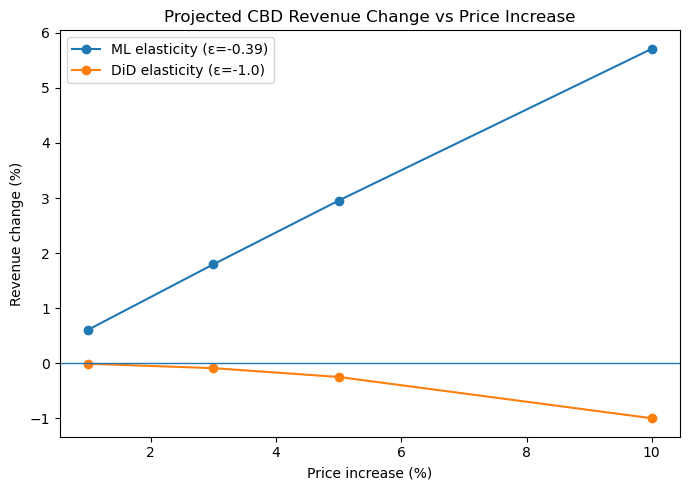

In [89]:
# Use your scenario outputs df_ml and df_did
x_ml = df_ml["price_change_pct"] * 100
y_ml = df_ml["revenue_change_pct"] * 100

x_did = df_did["price_change_pct"] * 100
y_did = df_did["revenue_change_pct"] * 100

plt.figure(figsize=(7,5))
plt.plot(x_ml, y_ml, marker="o", label="ML elasticity (ε=-0.39)")
plt.plot(x_did, y_did, marker="o", label="DiD elasticity (ε=-1.0)")
plt.axhline(0, linewidth=1)

plt.title("Projected CBD Revenue Change vs Price Increase")
plt.xlabel("Price increase (%)")
plt.ylabel("Revenue change (%)")
plt.legend()
plt.tight_layout()
plt.show()

Revenue vs Price Increase

Under the ML-estimated elasticity (–0.39), moderate fare increases (3–5%) are projected to raise CBD revenue by approximately 2–3%, as demand falls proportionally less than price rises. In contrast, the DiD elasticity (–1.0) suggests revenue remains roughly flat under larger price shocks, indicating that the initial congestion fee primarily reduced trips rather than increased revenue.

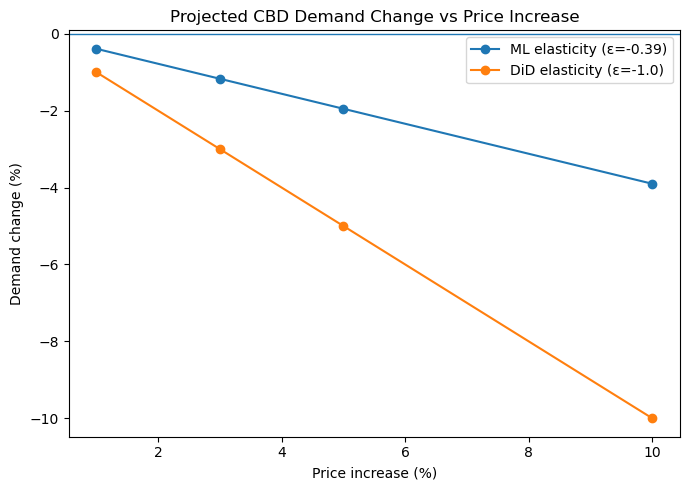

In [90]:
x_ml = df_ml["price_change_pct"] * 100
q_ml = df_ml["demand_change_pct"] * 100

x_did = df_did["price_change_pct"] * 100
q_did = df_did["demand_change_pct"] * 100

plt.figure(figsize=(7,5))
plt.plot(x_ml, q_ml, marker="o", label="ML elasticity (ε=-0.39)")
plt.plot(x_did, q_did, marker="o", label="DiD elasticity (ε=-1.0)")
plt.axhline(0, linewidth=1)

plt.title("Projected CBD Demand Change vs Price Increase")
plt.xlabel("Price increase (%)")
plt.ylabel("Demand change (%)")
plt.legend()
plt.tight_layout()
plt.show()

Demand vs. Price Increase

The DiD model predicts substantially larger demand reductions for fare increases, reflecting a strong behavioral response to the initial policy shock. Meanwhile, the ML model projects more moderate demand declines, suggesting that ongoing marginal price adjustments are less effective at reducing trip volume.

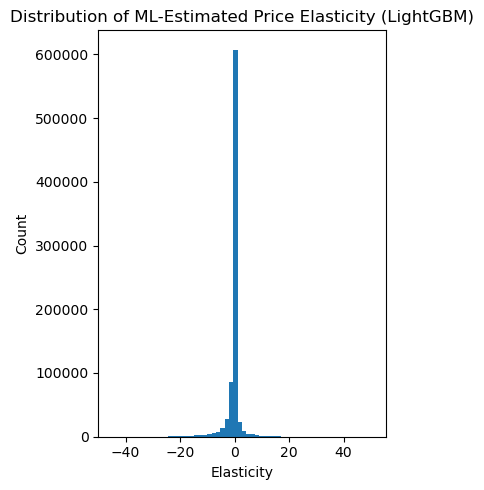

In [91]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(4,5))
plt.hist(eps_lgb, bins=60)
plt.title("Distribution of ML-Estimated Price Elasticity (LightGBM)")
plt.xlabel("Elasticity")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Elasticity Distribution (LightGBM)

The distribution of ML-estimated elasticities shows that most zone-hour observations cluster near zero, indicating limited marginal price sensitivity in many contexts. However, the negative tail pulls the average elasticity to approximately –0.39, highlighting meaningful heterogeneity in demand responsiveness across time and location.

In [92]:
# Get predictions
y_pred_rf = rf.predict(X_test)
py_pred_lgb = lgb_model.predict(X_test)

[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.2s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    1.2s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    1.3s finished


In [108]:
X_train_fe, y_train_fe = make_fe_xy(train_small)
X_test_fe,  y_test_fe  = make_fe_xy(test)

# Align columns (CRITICAL: ensures same dummy set)
X_test_fe = X_test_fe.reindex(columns=X_train_fe.columns, fill_value=0)

# Fit PanelOLS on train
res2_fe = PanelOLS(y_train_fe, X_train_fe, entity_effects=True).fit(
    cov_type="clustered",
    cluster_entity=True
)

# Predict on test
y_pred_fe = res2_fe.predict(X_test_fe)
# predict() can return Series/DataFrame depending on version
y_pred_fe = np.asarray(y_pred_fe).reshape(-1)

# Metrics
rmse_fe = np.sqrt(mean_squared_error(y_test_fe, y_pred_fe))
r2_fe   = r2_score(y_test_fe, y_pred_fe)

print("PanelOLS (FE) Test RMSE:", rmse_fe)
print("PanelOLS (FE) Test R²:", r2_fe)

PanelOLS (FE) Test RMSE: 0.8212936302923413
PanelOLS (FE) Test R²: 0.11233877490760946


In [109]:
print(len(y_pred_fe.flatten()))
print(len(y_pred_rf))
print(len(y_pred_lgb))
print(len(y_test.values))

817482
817482
817482
817482


In [110]:

# Create dataframe
df_plot = pd.DataFrame({
    "actual": y_test.values,
    "panel": y_pred_fe.flatten(),
    "rf": y_pred_rf,
    "lgb": y_pred_lgb
})

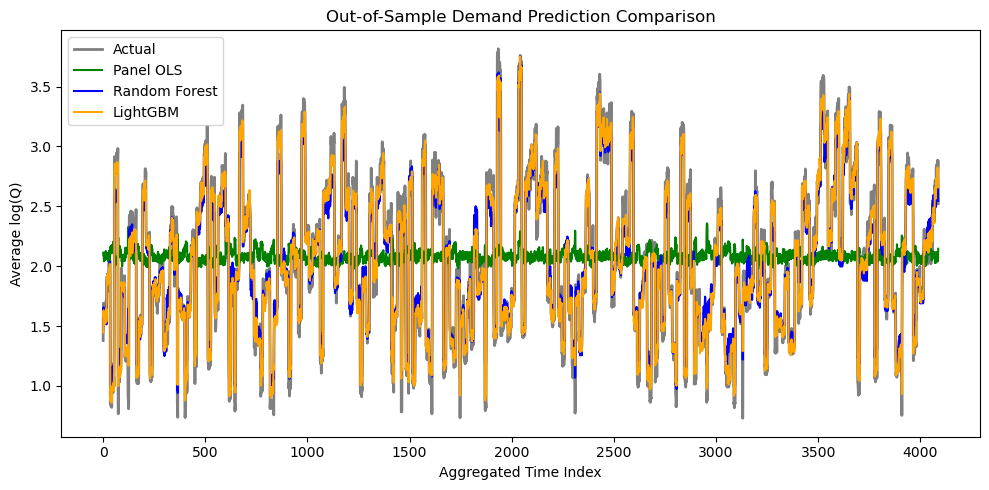

In [111]:

# Create dataframe
df_plot = pd.DataFrame({
    "actual": y_test.values,
    "panel": y_pred_fe.flatten(),
    "rf": y_pred_rf,
    "lgb": y_pred_lgb
})

# Aggregate every 200 observations (smooths the lines)
df_plot_agg = df_plot.groupby(df_plot.index // 200).mean()
plt.figure(figsize=(10,5))

plt.plot(df_plot_agg["actual"],
         color="grey",
         linewidth=2,
         label="Actual")

plt.plot(df_plot_agg["panel"],
         color="green",
         linewidth=1.5,
         label="Panel OLS")

plt.plot(df_plot_agg["rf"],
         color="blue",
         linewidth=1.5,
         label="Random Forest")

plt.plot(df_plot_agg["lgb"],
         color="orange",
         linewidth=1.5,
         label="LightGBM")

plt.legend()
plt.title("Out-of-Sample Demand Prediction Comparison")
plt.ylabel("Average log(Q)")
plt.xlabel("Aggregated Time Index")
plt.tight_layout()
plt.show()

